# GitHub User Activity Prediction

*   **Target:** Predict active users in the next hour (Class 1 = Active [29.5%], Class 0 = Inactive [70.5%]).
*   **Data State:** Imputed, 99th percentile capped, log-transformed, and scaled (StandardScaler). 
*   **Class Imbalance Ratio:** ~2.3 Inactive to 1 Active.
*   **Evaluation Metrics:** F1-Score and ROC-AUC (Accuracy is discouraged due to imbalance).

In [35]:
# Core Data Manipulation
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Machine Learning Models & Tuning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, f1_score, precision_recall_curve, auc
)

## Load Preprocessed Data
Loading the 80/20 train-test splits. 

Based on preprocessing step:
*   `payload_action`, `org`, `actor_id`, and `repo_id` were excluded.
*   `is_bot_suspect` is effectively zero-variance due to the 99th percentile capping (max 66.8 events), so we will drop it to prevent model noise.

In [36]:
# Load preprocessed datasets
X_train = pd.read_csv('preprocessed_data/X_train.csv')
X_test = pd.read_csv('preprocessed_data/X_test.csv')
y_train = pd.read_csv('preprocessed_data/y_train.csv').values.ravel()
y_test = pd.read_csv('preprocessed_data/y_test.csv').values.ravel()

# Sanity Check for zero-variance or identifying columns
cols_to_drop = [c for c in['is_bot_suspect', 'actor_id', 'repo_id'] if c in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# Calculate Imbalance Ratio for XGBoost
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Training Data Shape: {X_train.shape}")
print(f"Class 0 (Inactive): {(y_train == 0).sum()} | Class 1 (Active): {(y_train == 1).sum()}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Training Data Shape: (8099, 6)
Class 0 (Inactive): 5713 | Class 1 (Active): 2386
Imbalance Ratio: 2.39


## Modeling
We will train three distinct types of models to compare their performance:
1. **Logistic Regression:** A linear, highly interpretable baseline.
2. **Random Forest:** A robust bagging ensemble model.
3. **XGBoost:** A powerful gradient boosting algorithm.

To handle the 70.5% / 29.5% class imbalance, we apply class weighting techniques to all models (`class_weight='balanced'` and `scale_pos_weight`).

In [37]:
# Calculate imbalance ratio for XGBoost
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 1. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='auc', random_state=42, use_label_encoder=False)
}

# 2. Train Models
print("Training models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"✅ {name} trained.")

Training models...
✅ Logistic Regression trained.
✅ Random Forest trained.
✅ XGBoost trained.


## Evaluation & Model Comparison
Because of the class imbalance, an arbitrary threshold of 0.5 is not optimal. For a fair comparison, we will calculate the **optimal probability threshold** for each model that maximizes the **F1-Score**, and then compare their ROC-AUC and optimal F1-Scores.

In [38]:
from sklearn.metrics import precision_recall_curve

results_list =[]
roc_data = {}

for name, model in models.items():
    # Predict probabilities
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC-AUC
    auc_score = roc_auc_score(y_test, y_test_proba)
    
    # Calculate Precision-Recall Curve to find optimal F1 threshold
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) # avoid division by zero
    
    optimal_idx = np.argmax(f1_scores)
    best_threshold = thresholds[optimal_idx]
    best_f1 = f1_scores[optimal_idx]
    
    # Store data for ROC curve plotting
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_score}
    
    # Append metrics
    results_list.append({
        'Model': name,
        'ROC-AUC': auc_score,
        'Optimal F1-Score': best_f1,
        'Best Threshold': best_threshold
    })

# Create a Comparison DataFrame
df_results = pd.DataFrame(results_list).sort_values(by='Optimal F1-Score', ascending=False).reset_index(drop=True)
display(df_results.style.background_gradient(cmap='Blues', subset=['ROC-AUC', 'Optimal F1-Score']))

,Model,ROC-AUC,Optimal F1-Score,Best Threshold
0,Logistic Regression,0.727383,0.544974,0.427537
1,Random Forest,0.722978,0.542561,0.445313
2,XGBoost,0.720825,0.541063,0.455454


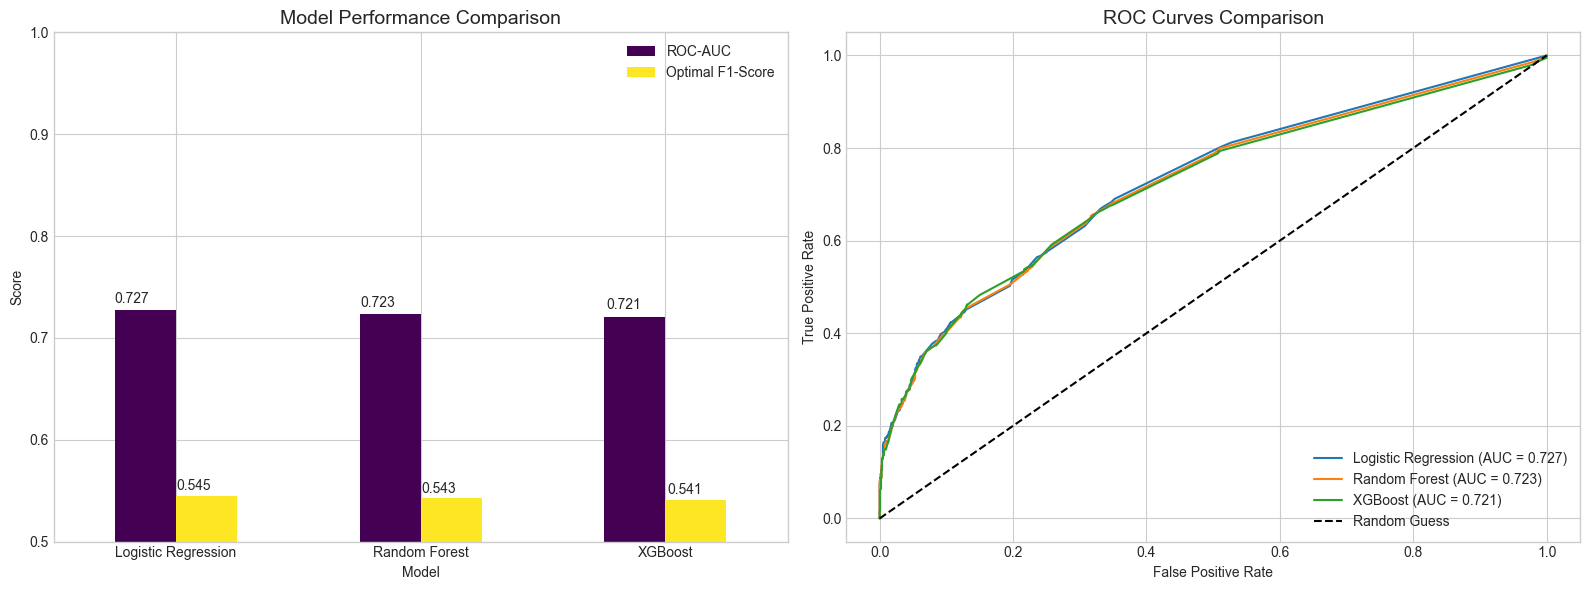

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart of Metrics
df_results.plot(x='Model', y=['ROC-AUC', 'Optimal F1-Score'], kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Model Performance Comparison', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() * 1.005, p.get_height() * 1.01))

# Plot 2: Combined ROC Curves
for name, data in roc_data.items():
    axes[1].plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curves Comparison', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Final Model Selection
Based on the comparative analysis, we programmatically select the model that achieved the highest **Optimal F1-Score**. We will use this model to extract feature importances and serialize it for deployment.

Selected Model: Logistic Regression
Operating Threshold: 0.4275


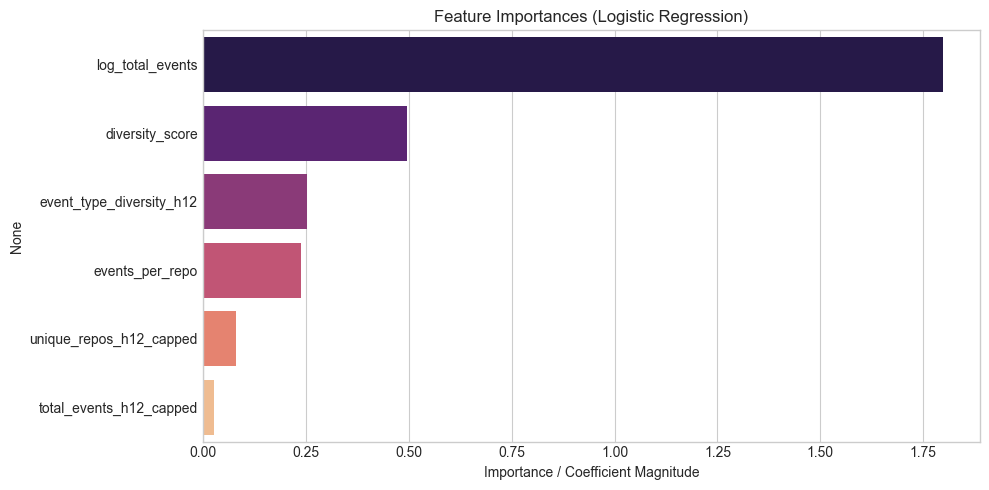

In [40]:
# Automatically select the best model based on F1-Score
best_model_name = df_results.iloc[0]['Model']
best_model = models[best_model_name]
final_threshold = df_results.iloc[0]['Best Threshold']

print(f"Selected Model: {best_model_name}")
print(f"Operating Threshold: {final_threshold:.4f}")

# Feature Importance mapping
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = best_model.feature_importances_
elif best_model_name == "Logistic Regression":
    importances = np.abs(best_model.coef_[0])

feat_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

# Plot Feature Importances of the WINNING model
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='magma')
plt.title(f'Feature Importances ({best_model_name})')
plt.xlabel('Importance / Coefficient Magnitude')
plt.tight_layout()
plt.show()

 * **ROC-AUC:** Logistic Regression achieved the highest ROC-AUC at **0.727**, followed closely by Random Forest (0.723) and XGBoost (0.721). An AUC of ~0.73 indicates that the model has a moderate, reliable ability to distinguish between users who will be active versus inactive in the next hour.
* **Optimal F1-Score:** Because the data has a 70/30 class imbalance, the Optimal F1-Score is our true north. Logistic Regression again edges out the competition with an F1-Score of **0.545**, compared to 0.543 and 0.541 for the tree-based models. 

The ROC Curves chart on the right visually confirms the metric similarities.

In [41]:
# Prepare Deployment Artifact
deployment_artifact = {
    'model_name': best_model_name,
    'model': best_model,
    'optimal_threshold': final_threshold,
    'features': list(X_train.columns)
}

os.makedirs('models', exist_ok=True)
model_path = 'models/best_github_activity_model.pkl'
joblib.dump(deployment_artifact, model_path)

print(f"✅ Deployment Artifact successfully saved to {model_path}")
print(f"Backend Instructions: Use `predict_proba(X)[:, 1] >= {final_threshold:.4f}` for final classification.")

✅ Deployment Artifact successfully saved to models/best_github_activity_model.pkl
Backend Instructions: Use `predict_proba(X)[:, 1] >= 0.4275` for final classification.


## Logistic Regression Insights

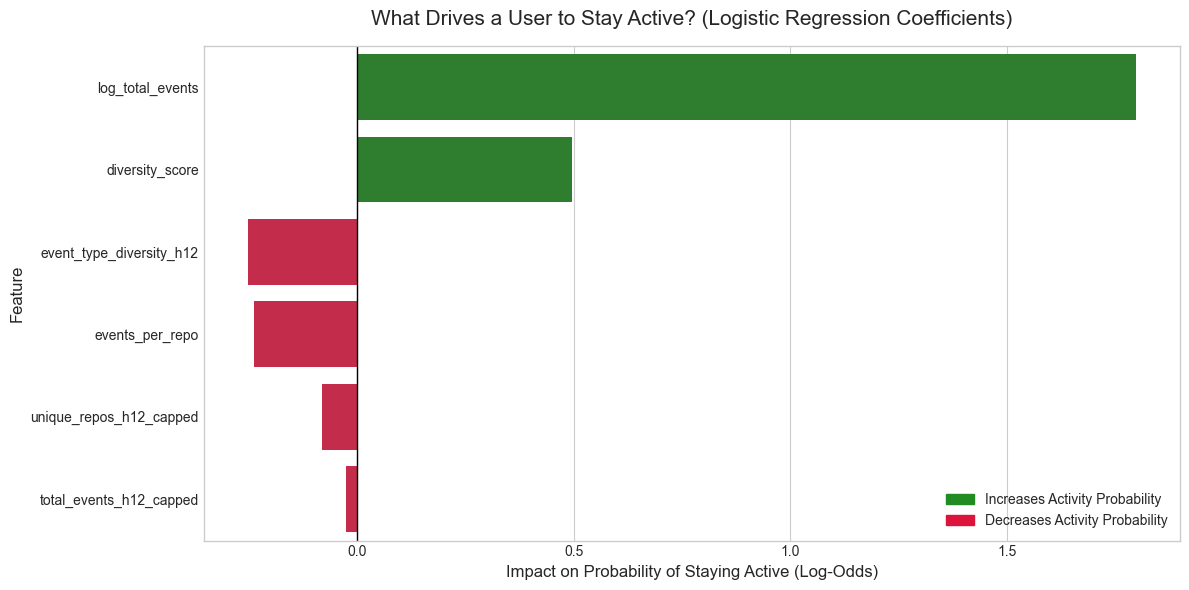

,Feature,Coefficient
5,log_total_events,1.797690
4,diversity_score,0.495619
1,event_type_diversity_h12,-0.252271
3,events_per_repo,-0.238889
2,unique_repos_h12_capped,-0.080762


In [42]:

import matplotlib.patches as mpatches

# Since Logistic Regression won, we can extract exact coefficients (weights)
# The data was StandardScaler, so the magnitude of the coefficient = its importance
coefficients = best_model.coef_[0]
features = X_train.columns

# Create a DataFrame for interpretation
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients)
}).sort_values(by='Absolute_Impact', ascending=False)

# Plotting the Directional Impact
plt.figure(figsize=(12, 6))

# Assign colors: Green for positive impact, Red for negative impact
colors =['forestgreen' if c > 0 else 'crimson' for c in coef_df['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

plt.title('What Drives a User to Stay Active? (Logistic Regression Coefficients)', fontsize=15, pad=15)
plt.xlabel('Impact on Probability of Staying Active (Log-Odds)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Custom legend
pos_patch = mpatches.Patch(color='forestgreen', label='Increases Activity Probability')
neg_patch = mpatches.Patch(color='crimson', label='Decreases Activity Probability')
plt.legend(handles=[pos_patch, neg_patch], loc='lower right')

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

display(coef_df[['Feature', 'Coefficient']].head(5))